In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from torchvision import utils
import seaborn as sns
import numpy as np
import time
import matplotlib.pyplot as plt
from utils import extract, linear_beta_schedule, UNet_cond

# Fix random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Data Load

In [2]:
# batch sizes
bs_train = 128
bs_test  = 128

# load the custom MNIST data
data = torch.load('mnist_custom.pt')

train_images = data['train_images'].float()
train_labels = data['train_labels'].long()
test_images  = data['test_images'].float()
test_labels  = data['test_labels'].long()

# check data
print("Train images:", train_images.shape)
print("Test images:", test_images.shape)
print("Train range:", train_images.min().item(), train_images.max().item())
print("Test range:", test_images.min().item(), test_images.max().item())

Train images: torch.Size([60000, 1, 20, 20])
Test images: torch.Size([10000, 1, 20, 20])
Train range: 0.0 1.0
Test range: 0.0 1.0


In [3]:
# add channel dimension and normalise to [-1, 1]
train_images = train_images * 2 - 1
test_images  = test_images * 2 - 1

train_dataset = TensorDataset(train_images, train_labels)
test_dataset  = TensorDataset(test_images, test_labels)

# --- loaders
test_dataloader  = DataLoader(test_dataset, batch_size=bs_test, shuffle=False, num_workers=0, pin_memory=False)
train_dataloader = DataLoader(train_dataset, batch_size=bs_train, shuffle=True, num_workers=0, pin_memory=False)

In [4]:
# check one batch
images, labels = next(iter(train_dataloader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)
print("Image range:", images.min().item(), images.max().item())

Image batch: torch.Size([128, 1, 20, 20])
Label batch: torch.Size([128])
Image range: -1.0 1.0


## Diffusion Process and Model Architecture

In [8]:
timesteps = 1000
betas = linear_beta_schedule(timesteps).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0).to(device)

    sqrt_alpha_bar = torch.sqrt(extract(alpha_bars, t, x0.shape))
    sqrt_one_minus_alpha_bar = torch.sqrt(extract(1 - alpha_bars, t, x0.shape))

    return sqrt_alpha_bar * x0 + noise * sqrt_one_minus_alpha_bar

In [6]:
extract(
    torch.sqrt(alpha_bars),
    torch.tensor([0, 1, 2, 300]).to(device),
    (4, 1, 20, 20)
)

tensor([[[[0.9999]]],


        [[[0.9999]]],


        [[[0.9998]]],


        [[[0.6277]]]], device='cuda:0')

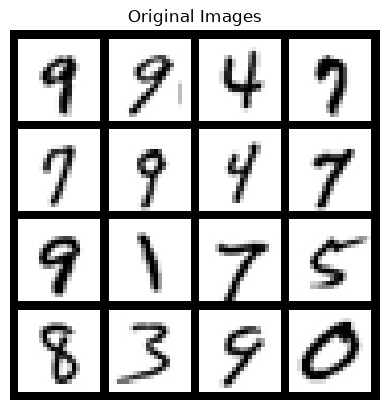

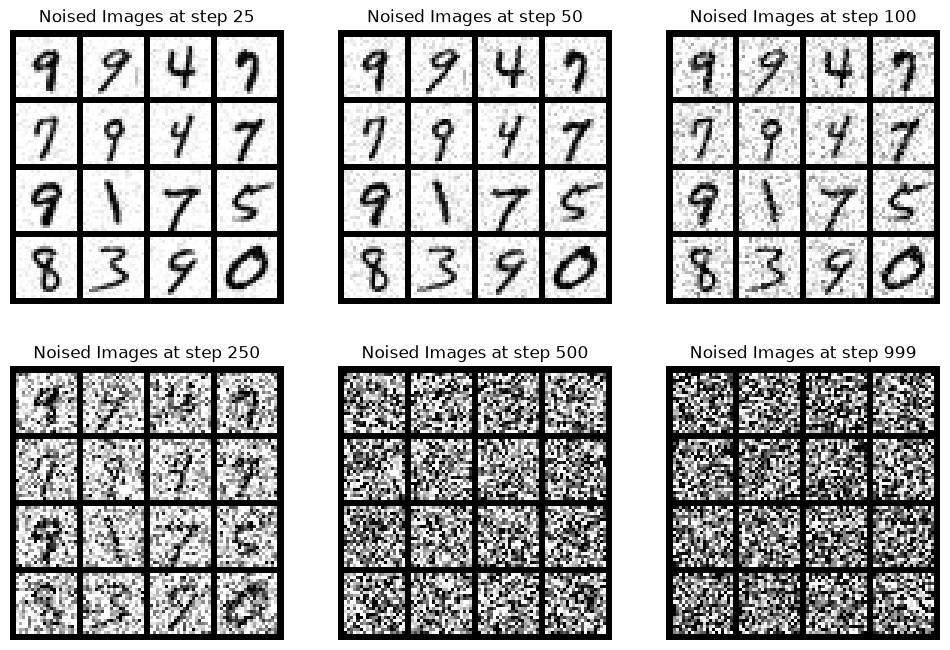

In [7]:
# check the forward diffusion process
img, label = next(iter(train_dataloader))
img = img[:16, :, :, :]

img_grid = utils.make_grid((img + 1) / 2, nrow=4)
plt.imshow(img_grid.permute(1, 2, 0).cpu())
plt.axis('off')
plt.title('Original Images')
plt.show()

img = img.to(device)

timesteps_investigated = [25, 50, 100, 250, 500, 999]
plt.figure(figsize=(12, 8))

for i, t in enumerate(timesteps_investigated):
    t = torch.tensor([t] * img.shape[0]).to(device)
    noised_img = q_sample(img, t)
    noised_img = noised_img.clamp(-1, 1)

    plt.subplot(2, 3, i + 1)
    img_grid = utils.make_grid((noised_img + 1) / 2, nrow=4)
    plt.imshow(img_grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title(f'Noised Images at step {timesteps_investigated[i]}')

plt.show()

In [8]:
channels = 1 # for MNIST
model_test = UNet_cond().to(device)
t_embed = model_test.time_mlp(torch.tensor([[10.],[500.],[999.]]).to(device)/timesteps)
print(t_embed.shape)
t_embed = t_embed.unsqueeze(-1).unsqueeze(-1)
print(t_embed.shape)
print(model_test.to_e1(t_embed).shape)
print(model_test.to_e2(t_embed).shape)

torch.Size([3, 32])
torch.Size([3, 32, 1, 1])
torch.Size([3, 32, 1, 1])
torch.Size([3, 64, 1, 1])


## Model using the linear_beta_schedule

In [9]:
runtime = time.time()

# Reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Training settings
image_size = 20
channels = 1  # for MNIST
epochs = 100
lr = 2e-4
n_channels_unet = 32

# Define model and optimiser
model = UNet_cond(ch=n_channels_unet, n_classes=10).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)

# Loss function
loss_fn = nn.MSELoss()

# Best model tracking
best_loss = float('inf')

# Store average loss for each epoch
loss_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    pbar = tqdm(
        iterable=train_dataloader,
        unit="batch",
        desc=f'training epoch {epoch+1}/{epochs}',
        colour='GREEN'
    )

    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        batch_size = imgs.shape[0]

        # Select a random timestep for each image
        t = torch.randint(
            0,
            timesteps,
            (batch_size,),
            device=device
        ).long()

        # Generate random noise
        noise = torch.randn_like(imgs)

        # Add noise to x_0 at timestep t
        x_t = q_sample(imgs, t, noise)

        # Predict the added noise
        pred_noise = model(x_t, t, labels)

        # Compare predicted noise with actual noise
        loss = loss_fn(pred_noise, noise)

        # Update model parameters
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Accumulate batch loss
        running_loss += loss.item()

        # Display current batch loss
        pbar.set_postfix(loss=loss.item())

    pbar.close()

    # Calculate average loss for this epoch
    epoch_loss = running_loss / len(train_dataloader)

    # Store epoch loss
    loss_history.append(epoch_loss)

    # Save model with the lowest epoch loss
    if epoch_loss < best_loss:
        best_loss = epoch_loss

        torch.save(
            model.state_dict(),
            "models/linear_best_model.pth"
        )

    print(
        f'Epoch {epoch+1}: '
        f'loss={epoch_loss:.6f}, '
        f'best_loss={best_loss:.6f}'
    )

# Save all epoch losses for main_report.ipynb
np.save(
    "models/linear_loss.npy",
    np.array(loss_history)
)

# Find best epoch from loss history
best_epoch = np.argmin(loss_history) + 1

print(f'Best epoch: {best_epoch}')
print(f'Best loss: {best_loss:.6f}')
print(f'Training time: {time.time()-runtime:.2f} seconds')

training epoch 1/100: 100%|██████████| 469/469 [00:08<00:00, 56.00batch/s, loss=0.108]


Epoch 1: loss=0.284331, best_loss=0.284331


training epoch 2/100: 100%|██████████| 469/469 [00:08<00:00, 56.64batch/s, loss=0.0613]


Epoch 2: loss=0.101042, best_loss=0.101042


training epoch 3/100: 100%|██████████| 469/469 [00:08<00:00, 56.65batch/s, loss=0.0838]


...

Epoch 98: loss=0.029502, best_loss=0.029381


training epoch 99/100: 100%|██████████| 469/469 [00:08<00:00, 56.19batch/s, loss=0.0329]


Epoch 99: loss=0.029472, best_loss=0.029381


training epoch 100/100: 100%|██████████| 469/469 [00:08<00:00, 56.20batch/s, loss=0.0356]


Epoch 100: loss=0.029579, best_loss=0.029381
Best epoch: 97
Best loss: 0.029381
Training time: 834.31 seconds


## Model using the cosine_beta_schedule

In [10]:
# Cosine beta schedule
def cosine_beta_schedule(timesteps, s=0.008):

    # Use T+1 points to calculate alpha_bar from t=0 to t=T
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)

    # Define alpha_bar using a cosine curve
    # alpha_bar represents how much of the original image is preserved
    alpha_bars = torch.cos(
        ((x / timesteps + s) / (1 + s)) * torch.pi * 0.5
    ) ** 2

    # Normalise so that alpha_bar starts at 1
    alpha_bars = alpha_bars / alpha_bars[0]

    # Calculate beta values from the cosine alpha_bar schedule
    betas = 1 - (alpha_bars[1:] / alpha_bars[:-1])

    # Keep beta values within a valid range
    return torch.clip(betas, 0.0001, 0.9999)


# Create the cosine noise schedule
betas = cosine_beta_schedule(timesteps).to(device)

# alpha = 1 - beta
alphas = 1.0 - betas

# Cumulative product of alpha
# Represents how much of the original image remains at each timestep
alpha_bars = torch.cumprod(alphas, dim=0)

In [11]:
runtime = time.time()

# Reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Training settings
image_size = 20
channels = 1  # for MNIST
epochs = 100
lr = 2e-4
n_channels_unet = 32

# Define a NEW model and optimiser for cosine schedule
model = UNet_cond(ch=n_channels_unet, n_classes=10).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)

# Loss function
loss_fn = nn.MSELoss()

# Best model tracking
best_loss = float('inf')

# Store average loss for each epoch
loss_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    pbar = tqdm(
        iterable=train_dataloader,
        unit="batch",
        desc=f'training epoch {epoch+1}/{epochs}',
        colour='GREEN'
    )

    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        batch_size = imgs.shape[0]

        # Select a random timestep for each image
        t = torch.randint(
            0,
            timesteps,
            (batch_size,),
            device=device
        ).long()

        # Generate random noise
        noise = torch.randn_like(imgs)

        # Add noise using the COSINE schedule
        x_t = q_sample(imgs, t, noise)

        # Predict the added noise
        pred_noise = model(x_t, t, labels)

        # Compare predicted noise with actual noise
        loss = loss_fn(pred_noise, noise)

        # Update model parameters
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Accumulate batch loss
        running_loss += loss.item()

        # Display current batch loss
        pbar.set_postfix(loss=loss.item())

    pbar.close()

    # Calculate average loss for this epoch
    epoch_loss = running_loss / len(train_dataloader)

    # Store epoch loss
    loss_history.append(epoch_loss)

    # Save model with the lowest epoch loss
    if epoch_loss < best_loss:
        best_loss = epoch_loss

        torch.save(
            model.state_dict(),
            "models/cosine_best_model.pth"
        )

    print(
        f'Epoch {epoch+1}: '
        f'loss={epoch_loss:.6f}, '
        f'best_loss={best_loss:.6f}'
    )

# Save all epoch losses for main_report.ipynb
np.save(
    "models/cosine_loss.npy",
    np.array(loss_history)
)

# Find best epoch
best_epoch = np.argmin(loss_history) + 1

print(f'Best epoch: {best_epoch}')
print(f'Best loss: {best_loss:.6f}')
print(f'Training time: {time.time()-runtime:.2f} seconds')

training epoch 1/100: 100%|██████████| 469/469 [00:08<00:00, 56.13batch/s, loss=0.147]


Epoch 1: loss=0.355574, best_loss=0.355574


training epoch 2/100: 100%|██████████| 469/469 [00:08<00:00, 56.11batch/s, loss=0.0983]


Epoch 2: loss=0.134678, best_loss=0.134678


training epoch 3/100: 100%|██████████| 469/469 [00:08<00:00, 56.09batch/s, loss=0.109] 


...

Epoch 98: loss=0.050020, best_loss=0.049796


training epoch 99/100: 100%|██████████| 469/469 [00:08<00:00, 56.18batch/s, loss=0.054] 


Epoch 99: loss=0.049972, best_loss=0.049796


training epoch 100/100: 100%|██████████| 469/469 [00:08<00:00, 56.30batch/s, loss=0.0579]


Epoch 100: loss=0.050031, best_loss=0.049796
Best epoch: 97
Best loss: 0.049796
Training time: 835.15 seconds


## Training Summary and Objective Interpretation

### 1. Training Outcomes & Loss Comparison

* **Linear Schedule Model:** Minimum training loss = **0.029381** (achieved at Epoch 97; runtime = 834.31s).
* **Cosine Schedule Model:** Minimum training loss = **0.049796** (achieved at Epoch 97; runtime = 835.15s).
* Both models were saved to `models/linear_best_model.pth` and `models/cosine_best_model.pth` along with their loss arrays.

### 2. Interpretation of Loss Differences

* The linear model achieved a lower minimum noise-prediction MSE than the cosine model. However, loss magnitudes should be interpreted cautiously because the schedules induce different timestep-dependent signal-to-noise distributions, so aggregate training loss is not a direct measure of final perceptual quality.

In diffusion models, the training loss is an unweighted average of MSE over uniformly sampled timesteps $t \sim \mathcal{U}(0, T-1)$. The linear schedule destroys signal rapidly at high $t$, resulting in a large fraction of steps where the model predicts noise from pure Gaussian noise (where target variance is low). The cosine schedule retains image structure across a wider range of timesteps, presenting a more difficult noise prediction task. Thus, the lower MSE of the linear model reflects the schedule corruption geometry rather than superior generative capability.

### 3. Checkpoint Selection & Limitations

* **Checkpoint Criterion:** Checkpoints were selected using minimum training loss because no validation-based selection metric was included during training. Consequently, checkpoint selection may not correspond exactly to the best generative performance.
* **Single Run Limitation:** Results represent a single controlled training run per schedule (seed 42). While architecture, learning rate ($2 \times 10^{-4}$), optimizer (Adam), batch size (128), and diffusion horizon ($T=1000$) were strictly controlled to isolate the schedule effect, stochastic diffusion dynamics mean multi-seed evaluations are recommended for full robustness.
* **Inference & Hypothesis Evaluation:** Model loading, generation of 120 samples per model, trajectory tracking, and reduced-step sampling experiments are carried out in `main_report.ipynb`.